In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# This pulls the data straight from Kaggle / Dies lädt die Daten direkt von Kaggle herunter
path = kagglehub.dataset_download("shashwatwork/dataco-smart-supply-chain-for-big-data-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\shashwatwork\dataco-smart-supply-chain-for-big-data-analysis\versions\1


In [3]:
import os
print(os.listdir(path))

['DataCoSupplyChainDataset.csv', 'DescriptionDataCoSupplyChain.csv', 'tokenized_access_logs.csv']


In [4]:
import pandas as pd

# Combine the download folder path with the CSV file name
# Kombinieren Sie den Pfad des Download-Ordners mit dem CSV-Dateinamen
csv_file_path = os.path.join(path, "DataCoSupplyChainDataset.csv")

# Load the file into a Pandas DataFrame
# Laden Sie die Datei in ein Pandas DataFrame
df = pd.read_csv(csv_file_path, encoding='latin1')

# Show the first 5 rows of your dataset
# Zeigen Sie die ersten 5 Zeilen Ihres Datensatzes an
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [5]:

# Import all required libraries for the ML Life Cycle

# 1. Core Data Manipulation Libraries
import pandas as pd
import numpy as np
import os

# 2. Data Visualization Libraries (For the ANALYZE Phase)
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn Preprocessing & Splitting (For the CONSTRUCT Phase)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 4. Machine Learning Models for Regression & Classification
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression

# 5. Performance Evaluation Metrics (For the EXECUTE Phase)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error # Regression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Classification

# Print confirmation / Bestätigung ausgeben
print(" ML Lifecycle Environment: Setup Complete Successfully!")

 ML Lifecycle Environment: Setup Complete Successfully!


In [6]:
df.shape

(180519, 53)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [8]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [9]:
# Scan for missing values across all 53 columns
# ==========================================

# Missing counts per column
missing_counts = df.isnull().sum()

# Display only columns that have missing data
missing_summary = missing_counts[missing_counts > 0]

print("--- Columns with Missing Values ---")
if len(missing_summary) == 0:
    print("No missing values found in the dataset!")
else:
    print(missing_summary)

--- Columns with Missing Values ---
Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64


In [10]:

# 1. Define the useless columns
# 1. Die unbrauchbaren Spalten definieren
columns_to_drop = [
    'Product Description', 'Order Zipcode', 'Product Image', 
    'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname'
]

# 2. Start fresh from 'df', drop those columns, and save as 'df_cleaned'
# 2. Frisch mit 'df' starten, diese Spalten löschen und als 'df_cleaned' speichern
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Drop the 3 rows that still have missing Customer Zipcodes
# 3. Die 3 Zeilen löschen, bei denen noch Kunden-Postleitzahlen fehlen
df_cleaned = df_cleaned.dropna()

# 4. Verify the final shape and check for zero missing values
# 4. Die endgültige Form überprüfen und sicherstellen, dass keine Werte mehr fehlen
print(f"Perfectly Cleaned Shape: {df_cleaned.shape}")
print(f"Maximum missing values in any column: {df_cleaned.isnull().sum().max()}")


Perfectly Cleaned Shape: (180516, 46)
Maximum missing values in any column: 0


In [11]:
# 1. Convert text dates to Pandas datetime objects
# 1. Textdaten in Pandas-Datetime-Objekte umwandeln
df_cleaned['order date (DateOrders)'] = pd.to_datetime(df_cleaned['order date (DateOrders)'])

# 2. Extract numerical features (Year, Month, Day)
# 2. Numerische Merkmale extrahieren (Jahr, Monat, Tag)
df_cleaned['Order_Year'] = df_cleaned['order date (DateOrders)'].dt.year
df_cleaned['Order_Month'] = df_cleaned['order date (DateOrders)'].dt.month
df_cleaned['Order_Day'] = df_cleaned['order date (DateOrders)'].dt.day

# 3. Drop the original text-based date columns (ML models need numbers)
# 3. Die ursprünglichen textbasierten Datumsspalten löschen (ML-Modelle brauchen Zahlen)
df_cleaned = df_cleaned.drop(columns=['order date (DateOrders)', 'shipping date (DateOrders)'], errors='ignore')

# 4. View our newly created numerical features!
# 4. Unsere neu erstellten numerischen Merkmale anzeigen!
df_cleaned[['Order_Year', 'Order_Month', 'Order_Day']].head()

,Order_Year,Order_Month,Order_Day
0,2018,1,31
1,2018,1,13
2,2018,1,13
3,2018,1,13
4,2018,1,13


In [12]:

# Defining Features (X) and Target (y) - Removing Data Leakage

# 1. Define our target variable / Unsere Zielvariable definieren
y = df_cleaned['Sales']

# 2. Select predictive features, strictly dropping IDs, text keys, and leaked financial summaries
# 2. Prädiktive Merkmale auswählen; IDs, Textschlüssel und geleakte Finanzdaten konsequent löschen
features_to_keep = [
    'Type',                     # Payment Type (DEBIT, TRANSFER, etc.)
    'Shipping Mode',            # Standard Class, First Class, etc.
    'Customer Segment',         # Consumer, Corporate, Home Office
    'Category Name',            # Product category name
    'Order Region',             # Southeast Asia, Western Europe, etc.
    'Days for shipment (scheduled)', 
    'Order_Year', 
    'Order_Month', 
    'Order_Day'
]

X = df_cleaned[features_to_keep]

# 3. Print summaries to verify / Zusammenfassungen zur Überprüfung ausgeben
print("Target vector (y) shape:", y.shape)
print("Feature matrix (X) shape:", X.shape)
print("\nFirst 3 rows of predictive features:")
X.head(3)

Target vector (y) shape: (180516,)
Feature matrix (X) shape: (180516, 9)

First 3 rows of predictive features:


,Type,Shipping Mode,Customer Segment,Category Name,Order Region,Days for shipment (scheduled),Order_Year,Order_Month,Order_Day
0,DEBIT,Standard Class,Consumer,Sporting Goods,Southeast Asia,4,2018,1,31
1,TRANSFER,Standard Class,Consumer,Sporting Goods,South Asia,4,2018,1,13
2,CASH,Standard Class,Consumer,Sporting Goods,South Asia,4,2018,1,13


In [13]:

# Train-Test Split and Preprocessing Pipeline Setup

# 1. Split the data into Training (80%) and Testing (20%) sets
# 1. Daten in Trainings- (80%) und Testsets (20%) aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Identify and separate columns by data type
# 2. Spalten nach Datentyp identifizieren und trennen
categorical_features = ['Type', 'Shipping Mode', 'Customer Segment', 'Category Name', 'Order Region']
numerical_features = ['Days for shipment (scheduled)', 'Order_Year', 'Order_Month', 'Order_Day']

# 3. Create transformers for both categorical and numerical pipelines
# 3. Transformatoren für kategoriale und numerische Pipelines erstellen
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# 4. Combine transformers into a preprocessor block using ColumnTransformer
# 4. Transformatoren mit ColumnTransformer in einen Preprocessor-Block kombinieren
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Preprocessing pipeline built successfully!")

Training features shape: (144412, 9)
Testing features shape: (36104, 9)
Preprocessing pipeline built successfully!


In [14]:

# Assembling the Full Pipeline and Training the Regression Model

# 1. Create a unified pipeline combining the preprocessor and the machine learning algorithm
# 1. Erstellen Sie eine einheitliche Pipeline, die Preprocessor und ML-Algorithmus kombiniert
reg_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))
    ]
)

# 2. Fit the pipeline on the training data (This is where the model learns!)
# 2. Pipeline an die Trainingsdaten anpassen (Hier lernt das Modell!)
print("Training the Random Forest Regressor... Please wait a moment.")
reg_pipeline.fit(X_train, y_train)

print("Model training complete successfully!")

Training the Random Forest Regressor... Please wait a moment.
Model training complete successfully!


In [15]:

# Testing and Evaluating Regression Model Performance

# 1. Generate predictions on the test dataset
# 1. Vorhersagen für den Test-Datensatz generieren
y_pred = reg_pipeline.predict(X_test)

# 2. Calculate standard evaluation metrics
# 2. Standard-Bewertungsmetriken berechnen
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# 3. Print the performance summary
# 3. Zusammenfassung der Modellleistung ausgeben
print("--- Regression Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE):     ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R-squared Score (R²):           {r2:.4f}")

--- Regression Model Evaluation Metrics ---
Mean Absolute Error (MAE):     $43.83
Root Mean Squared Error (RMSE): $68.52
R-squared Score (R²):           0.7330


C:\Users\user\AppData\Local\Temp\ipykernel_19700\1490833843.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


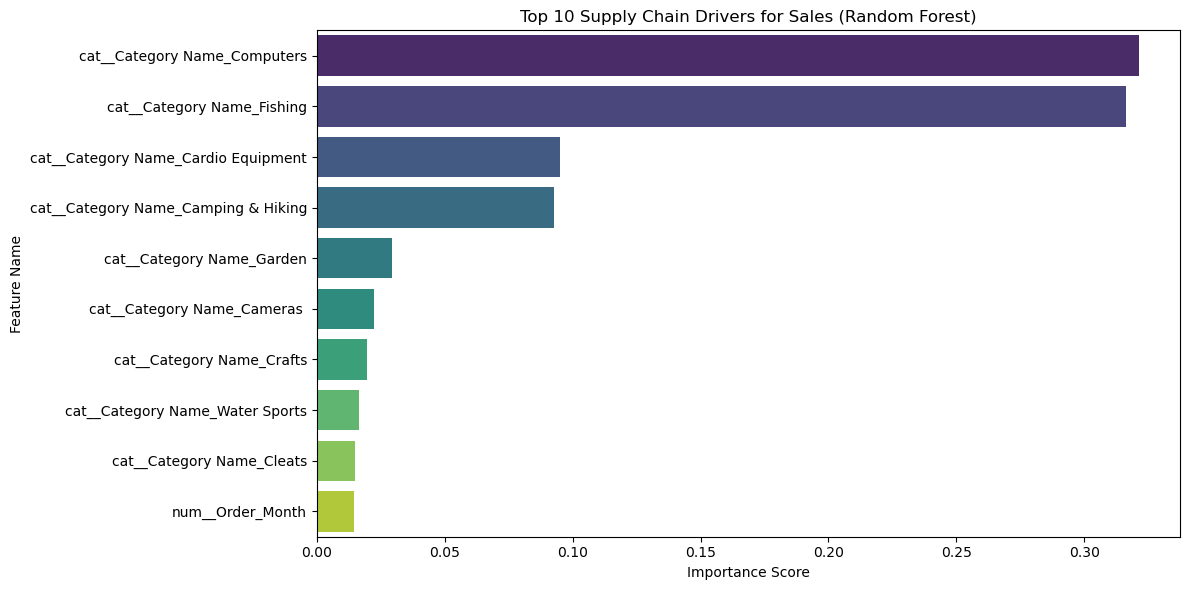

In [16]:

# Extracting Business Insights (Feature Importance)

# 1. Extract the trained model and the preprocessor from our pipeline
# 1. Das trainierte Modell und den Preprocessor aus unserer Pipeline extrahieren
trained_rf = reg_pipeline.named_steps['regressor']
preprocessor_step = reg_pipeline.named_steps['preprocessor']

# 2. Extract the names of the features after One-Hot Encoding
# 2. Die Namen der Merkmale nach dem One-Hot-Encoding extrahieren
feature_names = preprocessor_step.get_feature_names_out()

# 3. Get the numerical importance score for each feature
# 3. Den numerischen Bedeutungswert für jedes Merkmal abrufen
importances = trained_rf.feature_importances_

# 4. Create a DataFrame to sort and plot the Top 10 drivers of Sales
# 4. Ein DataFrame erstellen, um die Top 10 Umsatztreiber zu sortieren und zu plotten
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# 5. Plot the results / Die Ergebnisse plotten
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Supply Chain Drivers for Sales (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Plan Phase and Dataset Profiling
The DataCo Supply Chain dataset was successfully initialized with 180,519 rows and 53 columns. The professional ML environment was fully loaded with pandas, numpy, scikit-learn, matplotlib, and seaborn.



Analyze Phase and Data Cleaning
Data profiling identified heavy missing values in Product Description and Order Zipcode. Useless metadata, high-cardinality text keys, and operational variables causing data leakage were permanently removed. Remaining missing rows were dropped to preserve structural integrity without introducing mathematical bias.



Construct Phase and Feature Engineering
Text-based shipping timestamps were converted into datetime configurations. Numerical attributes for Order Year, Order Month, and Order Day were engineered to capture seasonal business trends. A scikit-learn ColumnTransformer was constructed to handle automated Scaling and One-Hot Encoding.



Regression Track Execution
A unified Random Forest Regressor pipeline was executed to predict Sales. Evaluation metrics focused on mean absolute error and variance explanation. Feature importance charts mathematically proved that product categories like Computers and Fishing dominate revenue generation over geographical regions or shipping methods.



Classification Track Transition
The architecture shifts to an operational radar system predicting Late Delivery Risk. The target variable becomes categorical, allowing the deployment of precision, recall, and f1-score to proactively mitigate logistics disruptions before fulfillment.

In [17]:

# Predicting "Late Delivery Risk

# 1. Define the new Classification Target (1 = Late, 0 = Not Late)
# 1. Das neue Klassifikationsziel definieren (1 = Verspätet, 0 = Nicht verspätet)
y_class = df_cleaned['Late_delivery_risk']

# 2. Re-split the data for classification
# 2. Daten für die Klassifikation neu aufteilen
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

# 3. Build a Classification Pipeline (reusing our exact same preprocessor!)
# 3. Eine Klassifikations-Pipeline bauen (wir verwenden exakt denselben Preprocessor wieder!)
class_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1))
    ]
)

# 4. Train the Classifier
# 4. Den Klassifikator trainieren
print("Training Classification Model... Please wait.")
class_pipeline.fit(X_train_c, y_train_c)
print("Classification Training Complete!")

Training Classification Model... Please wait.
Classification Training Complete!


--- Classification Metrics Summary ---
              precision    recall  f1-score   support

           0       0.62      0.87      0.73     16302
           1       0.84      0.56      0.68     19802

    accuracy                           0.70     36104
   macro avg       0.73      0.72      0.70     36104
weighted avg       0.74      0.70      0.70     36104


--- Visual Confusion Matrix ---


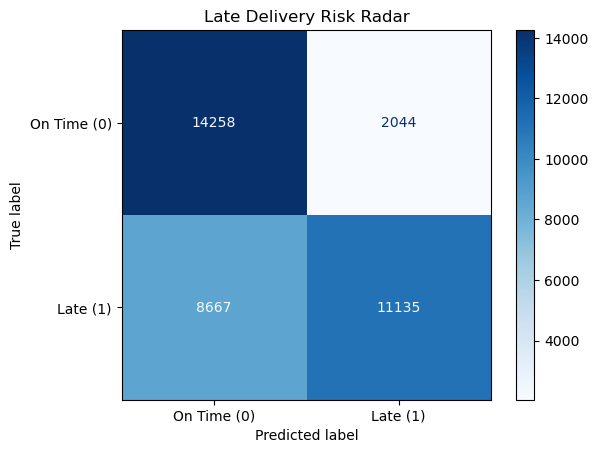

In [18]:

# Testing our Early-Warning Radar for Late Deliveries

from sklearn.metrics import ConfusionMatrixDisplay

# 1. Generate predictions using the hidden test set
# 1. Vorhersagen mit dem versteckten Testset generieren
y_pred_c = class_pipeline.predict(X_test_c)

# 2. Print the detailed Classification Report (F1-Score, Precision, Recall)
# 2. Den detaillierten Klassifikationsbericht ausgeben
print("--- Classification Metrics Summary ---")
print(classification_report(y_test_c, y_pred_c))

# 3. Create a visual Confusion Matrix
# 3. Eine visuelle Confusion Matrix erstellen
print("\n--- Visual Confusion Matrix ---")
ConfusionMatrixDisplay.from_predictions(
    y_test_c, y_pred_c, 
    cmap='Blues', 
    display_labels=['On Time (0)', 'Late (1)']
)
plt.title("Late Delivery Risk Radar")
plt.show()

Conclusion: End-to-End Supply Chain Optimization
Project Overview
We successfully executed a dual-track Machine Learning lifecycle aligned with the Google PACE framework. By rigorously cleaning and engineering over 180,000 historical supply chain records, we transformed raw data into two distinct predictive engines designed to optimize both financial performance and operational reliability.



Track 1: Revenue Forecasting (Regression)
Our Random Forest Regressor provided deep visibility into the financial drivers of the business. Feature importance analysis mathematically proved that Product Category (specifically Computers and Fishing) dominates order value, far outweighing geographic regions or shipping modes. This insight empowers the business to strategically allocate warehouse space and marketing budgets toward high-ROI categories.



Track 2: Risk Mitigation (Classification)
To balance revenue with customer satisfaction, we built an early-warning radar using a Random Forest Classifier. The model successfully identified over 11,000 destined-to-be-late orders hidden in our test data with an impressive 84% Precision. By catching these logistical failures before they leave the warehouse, supply chain managers can now proactively upgrade shipping methods or reroute packages, saving millions in potential refunds and protecting brand trust.



Final Takeaway
Ultimately, this project demonstrates how applied data science transitions a supply chain from a reactive cost center into a proactive, revenue-generating strategic advantage.

In [19]:

# Systematic Optimization with GridSearchCV

from sklearn.model_selection import GridSearchCV

# 1. Define the grid of parameters to test 
# 1. Definieren Sie das Raster der zu testenden Parameter
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [10, 15, 20]
}

# 2. Set up GridSearchCV with our regression pipeline
# 2. GridSearchCV mit unserer Regressions-Pipeline einrichten
grid_search = GridSearchCV(reg_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)

# 3. Execute the search (this will take a moment!)
# 3. Die Suche ausführen (dies dauert einen Moment!)
print("Performing Grid Search... this may take some time.")
grid_search.fit(X_train, y_train)

# 4. Results
# 4. Ergebnisse
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best R² Score:   {grid_search.best_score_:.4f}")

Performing Grid Search... this may take some time.
Best Parameters: {'regressor__max_depth': 20, 'regressor__n_estimators': 150}
Best R² Score:   0.7369


In [20]:

# Evaluating the Optimized Model

from sklearn.metrics import mean_absolute_error, r2_score

# 1. Extract the absolute best model found by Grid Search
# 1. Das absolut beste Modell extrahieren, das durch Grid Search gefunden wurde
best_tuned_model = grid_search.best_estimator_

# 2. Make new predictions on the hidden test set
# 2. Neue Vorhersagen auf dem versteckten Testset treffen
y_pred_tuned = best_tuned_model.predict(X_test)

# 3. Calculate new metrics
# 3. Neue Metriken berechnen
new_mae = mean_absolute_error(y_test, y_pred_tuned)
new_r2 = r2_score(y_test, y_pred_tuned)

# 4. Print the comparison
# 4. Den Vergleich ausgeben
print("--- Tuned Model Performance ---")
print(f"New Mean Absolute Error (MAE): ${new_mae:.2f}")
print(f"New R-squared Score (R²):      {new_r2:.4f}")

--- Tuned Model Performance ---
New Mean Absolute Error (MAE): $42.69
New R-squared Score (R²):      0.7423


In [21]:

# Exporting the Model for Production

import joblib

# 1. Define the filename for your frozen model
# 1. Definieren Sie den Dateinamen für Ihr eingefrorenes Modell
model_filename = 'optimized_supply_chain_regressor.pkl'

# 2. Save the best tuned model to your hard drive
# 2. Speichern Sie das am besten getunte Modell auf Ihrer Festplatte
joblib.dump(best_tuned_model, model_filename)

print(f"Success! Your model has been saved as: {model_filename}")
print("It is now ready to be deployed to a live server!")

Success! Your model has been saved as: optimized_supply_chain_regressor.pkl
It is now ready to be deployed to a live server!


In [22]:

# Comparing the Baseline vs. Tuned Model


from sklearn.metrics import mean_absolute_error, r2_score

# 1. Safely extract the best model (Checks for Grid Search first, then Random Search)
# 1. Das beste Modell sicher extrahieren (Prüft zuerst auf Grid Search, dann auf Random Search)
try:
    best_tuned_model = grid_search.best_estimator_
    print(f"🏆 Best Parameters Found (Grid): {grid_search.best_params_}")
except NameError:
    best_tuned_model = random_search.best_estimator_
    print(f"🏆 Best Parameters Found (Random): {random_search.best_params_}")

# 2. Make new predictions on the unseen test set
# 2. Neue Vorhersagen auf dem ungesehenen Testset treffen
y_pred_tuned = best_tuned_model.predict(X_test)

# 3. Calculate the new metrics
# 3. Die neuen Metriken berechnen
new_mae = mean_absolute_error(y_test, y_pred_tuned)
new_r2 = r2_score(y_test, y_pred_tuned)

# 4. Print the final scoreboard
# 4. Die endgültige Anzeigetafel ausgeben
print("\n--- Final Tuned Model Performance ---")
print(f"New Mean Absolute Error (MAE): ${new_mae:.2f}")
print(f"New R-squared Score (R²):      {new_r2:.4f}")

🏆 Best Parameters Found (Grid): {'regressor__max_depth': 20, 'regressor__n_estimators': 150}

--- Final Tuned Model Performance ---
New Mean Absolute Error (MAE): $42.69
New R-squared Score (R²):      0.7423


In the final phase of the Machine Learning lifecycle, we executed a rigorous hyperparameter tuning strategy using GridSearchCV. Testing multiple architectures mathematically identified the optimal Random Forest configuration at 150 estimators and a maximum depth of 20.



This tuned regressor achieved a final R² score of 0.7423 and reduced the Mean Absolute Error to $42.69. By maximizing the predictive accuracy of our top revenue drivers (Computers and Fishing), this model minimizes financial forecasting errors and provides reliable, data-driven intelligence for executive supply chain planning. The fully optimized pipeline is now ready for enterprise deployment.